In [8]:
#Carregar as bibliotecas

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os
import cv2
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.math import confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
tf.random.set_seed(3)

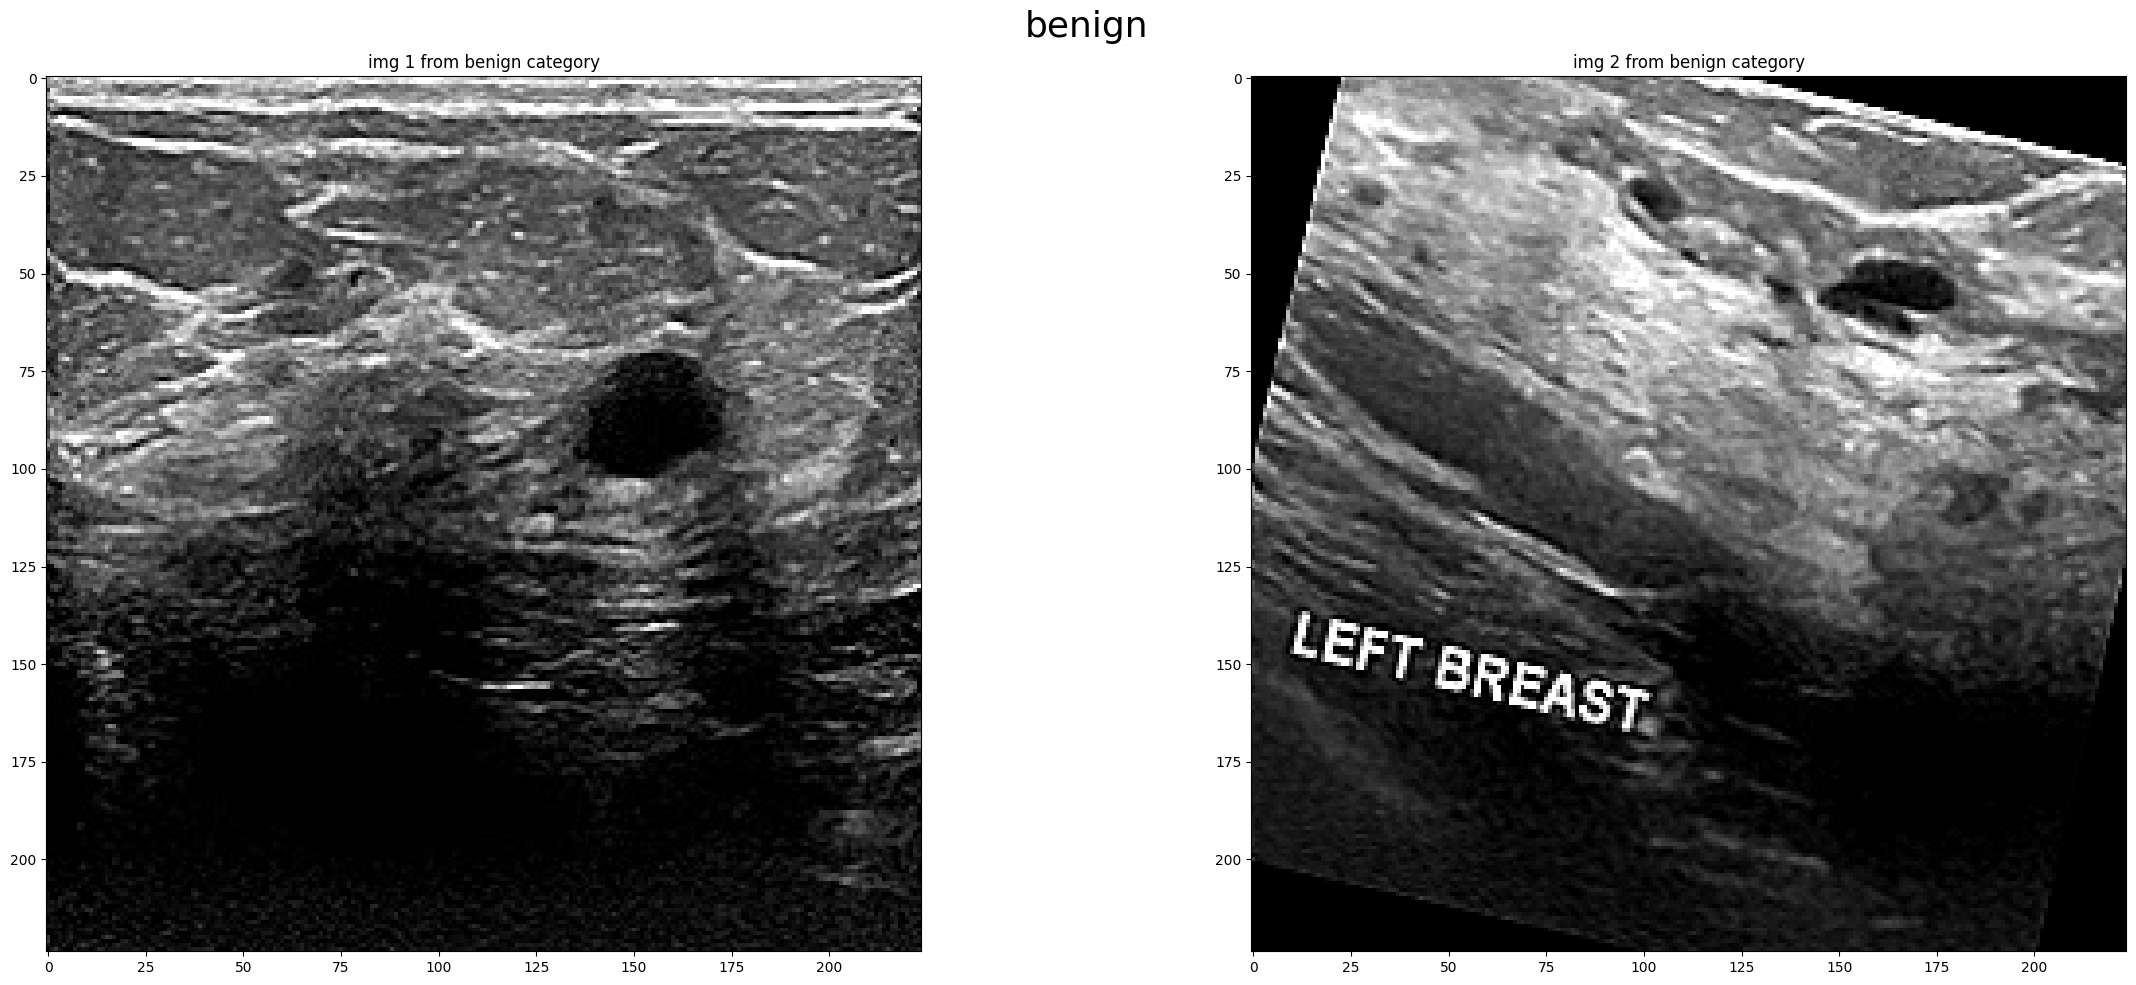

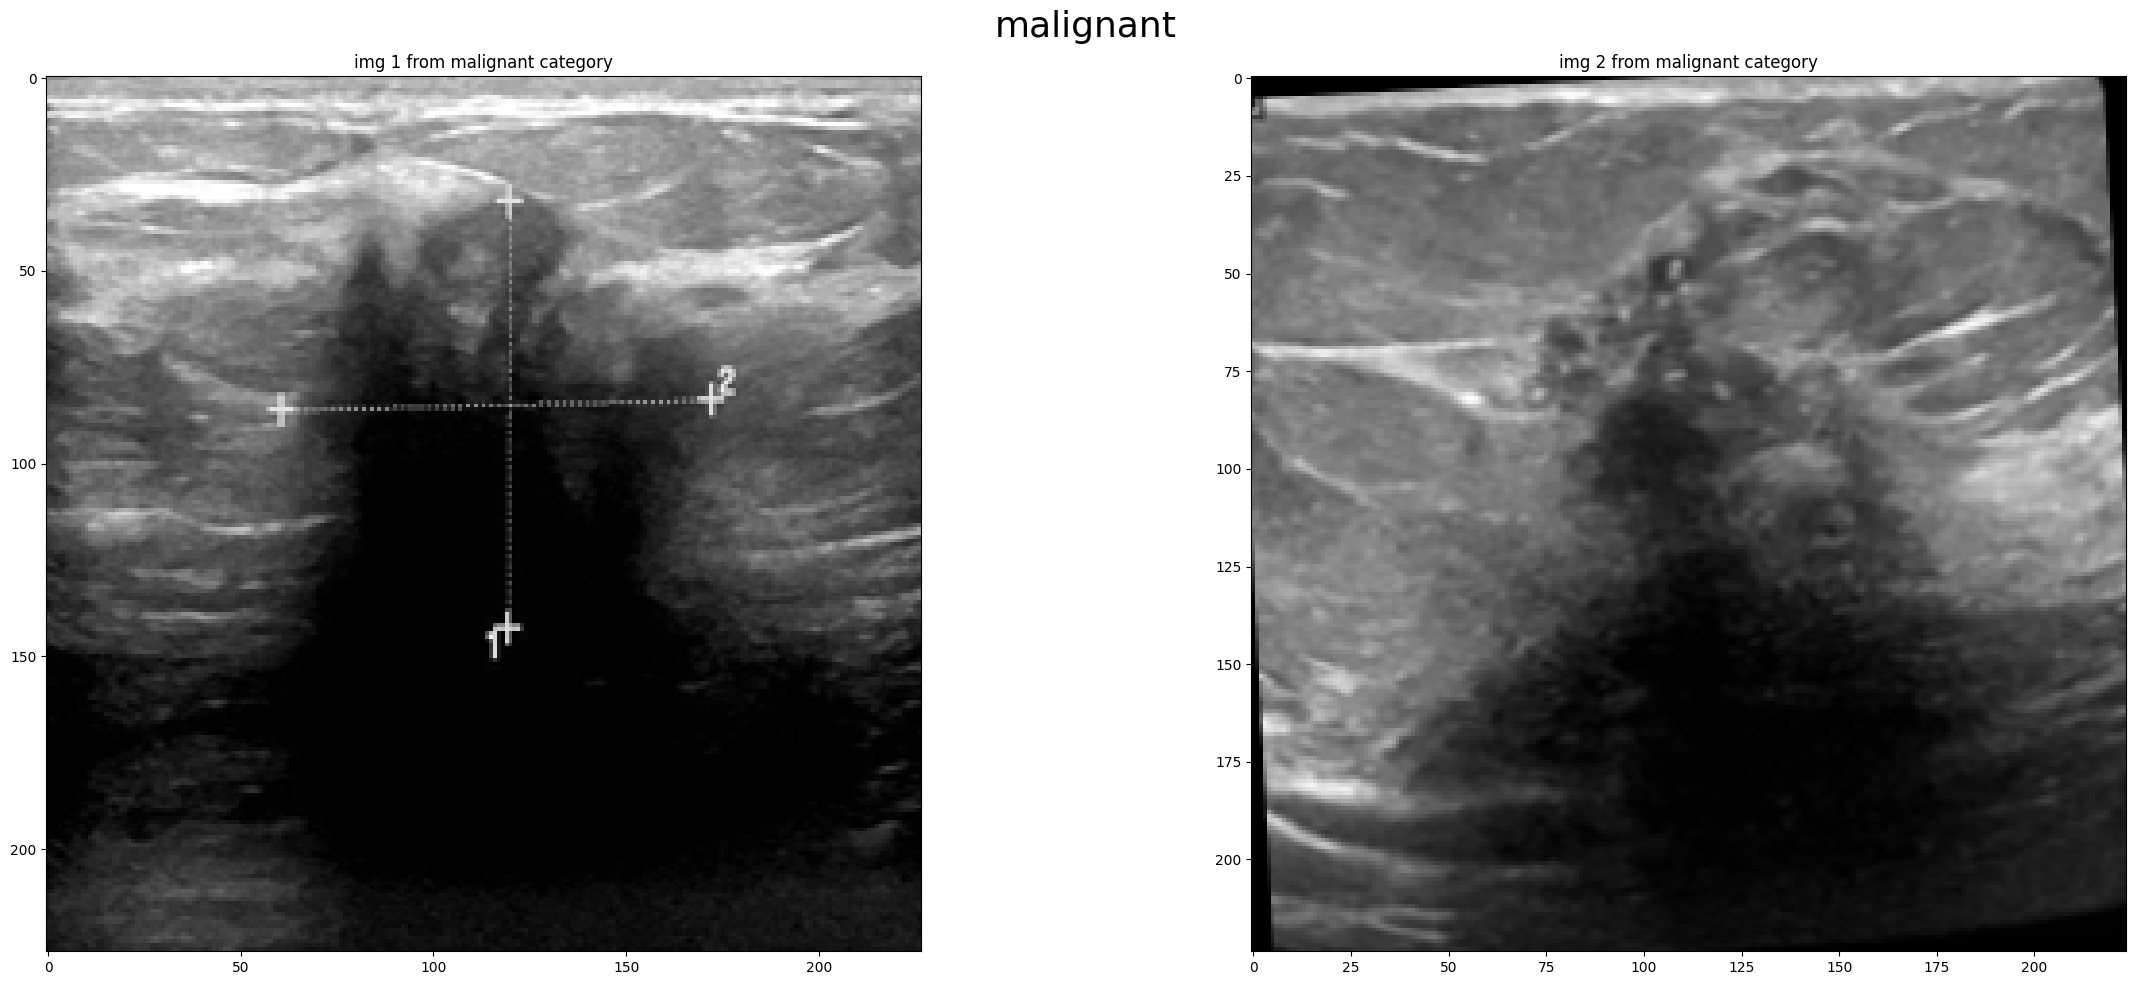

In [9]:
#Dados sobre conjunto de imagens de ultrassom de mama que contém 2 Classes [benigno, maligno] Exibindo 2 imagens de cada classe

import os
import cv2
import matplotlib.pyplot as plt

# Novo caminho da base de dados
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/train'
files_names = ['benign', 'malignant']  # Apenas as duas classes desejadas

for file in files_names:
    path = os.path.join(folder_name, file)
    x = 0
    fig, axes = plt.subplots(1, 2, figsize=(25, 10))  
    
    for img in os.listdir(path):
        if not img.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue  # Ignora arquivos que não são imagens

        img_path = os.path.join(path, img)
        if not os.path.isfile(img_path):
            continue  # Garante que é um arquivo

        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            continue  # Ignora arquivos corrompidos ou inválidos

        axes[x].imshow(img_array, cmap='gray')
        axes[x].set_title(f"img {x+1} from {file} category")
        x += 1
        if x == 2: 
            break

    plt.suptitle(file, fontsize=26)
    plt.tight_layout()
    plt.show()

In [10]:
# Carregando dados

import os
import cv2
from tqdm import tqdm

# Caminho para a pasta contendo as imagens de treino
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/train'

# Classes que queremos carregar
files_names = ['benign', 'malignant']

# Tamanho das imagens
img_sz = 224

# Lista para armazenar os dados de treino
training_data = []

def create_training_data():
    for file in files_names:
        path = os.path.join(folder_name, file)
        class_num = files_names.index(file)  # 0 para benign, 1 para malignant
        print(file, class_num)

        for img in tqdm(os.listdir(path)):
            img_path = os.path.join(path, img)

            # Filtros para evitar imagens indesejadas
            if not img.lower().endswith('.png'):
                continue
            if not os.path.isfile(img_path):
                continue

            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_array is None:
                continue  # evita erro se a imagem estiver corrompida

            new_array = cv2.resize(img_array, (img_sz, img_sz))
            training_data.append([new_array, class_num])

# Executar a função
create_training_data()


benign 0


100%|█████████████████████████████████████| 4074/4074 [00:02<00:00, 1483.88it/s]


malignant 1


100%|█████████████████████████████████████| 4042/4042 [00:03<00:00, 1233.72it/s]


In [11]:
# Os dados têm imagens benignas e malignas. Embaralhando e exibindo as primeiras 20 classes

import random

# Embaralha os dados de treino
random.shuffle(training_data)

# Exibe as primeiras 30 amostras com suas classes
for i in range(30):
    print(f"Sample {i+1}:")
    print("Class number:", training_data[i][1], "\n")


Sample 1:
Class number: 0 

Sample 2:
Class number: 1 

Sample 3:
Class number: 0 

Sample 4:
Class number: 1 

Sample 5:
Class number: 0 

Sample 6:
Class number: 0 

Sample 7:
Class number: 1 

Sample 8:
Class number: 0 

Sample 9:
Class number: 1 

Sample 10:
Class number: 0 

Sample 11:
Class number: 0 

Sample 12:
Class number: 0 

Sample 13:
Class number: 0 

Sample 14:
Class number: 0 

Sample 15:
Class number: 0 

Sample 16:
Class number: 0 

Sample 17:
Class number: 0 

Sample 18:
Class number: 0 

Sample 19:
Class number: 1 

Sample 20:
Class number: 0 

Sample 21:
Class number: 0 

Sample 22:
Class number: 0 

Sample 23:
Class number: 1 

Sample 24:
Class number: 0 

Sample 25:
Class number: 0 

Sample 26:
Class number: 0 

Sample 27:
Class number: 0 

Sample 28:
Class number: 0 

Sample 29:
Class number: 1 

Sample 30:
Class number: 0 



In [12]:
import numpy as np

X = []
y = []

# Percorre as amostras de treinamento
for feature, label in training_data:
    X.append(feature)
    y.append(label)

# Converte as listas em arrays numpy
X = np.array(X)
y = np.array(y)

# Adiciona a dimensão para o canal (escala de cinza)
X = np.expand_dims(X, axis=-1)  # Adiciona a dimensão do canal de cor (1 para grayscale)

# Verificando a forma de X e y
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (7352, 224, 224, 1)
y shape: (7352,)


In [13]:
from sklearn.model_selection import train_test_split

# Divisão dos dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar as formas dos conjuntos de dados
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(5881, 224, 224, 1)
(5881,)
(1471, 224, 224, 1)
(1471,)


In [14]:
# Valores únicos em y (Classes)

print(np.unique(y_train))

print(np.unique(y_test))

[0 1]
[0 1]


In [15]:
# Normalização para 0-1
X_train = X_train/255
X_test = X_test/255

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models

def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]
    
    shared_layer_one = layers.Dense(channel // ratio,
                                    activation='relu',
                                    kernel_initializer='he_normal',
                                    use_bias=True,
                                    bias_initializer='zeros')
    shared_layer_two = layers.Dense(channel,
                                    kernel_initializer='he_normal',
                                    use_bias=True,
                                    bias_initializer='zeros')

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)

    cbam_feature = layers.Add()([avg_pool, max_pool])
    cbam_feature = layers.Activation('sigmoid')(cbam_feature)

    return layers.Multiply()([input_feature, cbam_feature])

def spatial_attention(input_feature):
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(input_feature)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(input_feature)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    cbam_feature = layers.Conv2D(filters=1,
                                 kernel_size=7,
                                 strides=1,
                                 padding='same',
                                 activation='sigmoid',
                                 kernel_initializer='he_normal',
                                 use_bias=False)(concat)
    return layers.Multiply()([input_feature, cbam_feature])

# Em ultrassom (textura fina), ratios menores funcionam melhor.
def cbam_block(input_feature, ratio=4): #Ajustar o ratio do Channel Attention
    feature = channel_attention(input_feature, ratio)
    feature = spatial_attention(feature)
    return feature

# Agora o modelo com CBAM
img_sz = 224  # Exemplo de tamanho de imagem

inputs = layers.Input(shape=(img_sz, img_sz, 1))
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = cbam_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = cbam_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(128, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = cbam_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(256, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = cbam_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(2, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

I0000 00:00:1775876466.236878    8069 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9932 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Ti, pci bus id: 0000:08:00.0, compute capability: 8.6


In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 224, 224,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_8[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv2d_8[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_9 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1, 1, 8)   │        264 │ reshape_8[0][0],  │
│                     │                   │            │ reshape_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1, 1, 32)  │        288 │ dense_11[0][0],   │
│                     │                   │            │ dense_11[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 1, 1, 32)  │          0 │ dense_12[0][0],   │
│                     │                   │            │ dense_12[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 1, 1, 32)  │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_8          │ (None, 224, 224,  │          0 │ conv2d_8[0][0],   │
│ (Multiply)          │ 32)               │            │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 224, 224,  │          0 │ multiply_8[0][0]  │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 224, 224,  │          0 │ multiply_8[0][0]  │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 224, 224,  │          0 │ lambda_8[0][0],   │
│ (Concatenate)       │ 2)                │            │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 224, 224,  │         98 │ concatenate_4[0]… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 224, 224,  │          0 │ multiply_8[0][0], │
│ (Multiply)          │ 32)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ multiply_9[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 475,554 (1.81 MB)

 Trainable params: 474,594 (1.81 MB)

 Non-trainable params: 960 (3.75 KB)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',  # ou 'val_accuracy'
                               patience=10,          # número de épocas sem melhora antes de parar
                               restore_best_weights=True)  # restaura os melhores pesos

history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_split=0.2,
                    batch_size=8,
                    callbacks=[early_stopping])

2026-04-11 00:03:16.835587: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 944111616 exceeds 10% of free system memory.
2026-04-11 00:03:17.688094: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 944111616 exceeds 10% of free system memory.


Epoch 1/50


2026-04-11 00:03:20.896311: I external/local_xla/xla/service/service.cc:163] XLA service 0x7812b802dcf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-11 00:03:20.896323: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti, Compute Capability 8.6
2026-04-11 00:03:20.982699: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-11 00:03:21.572667: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000


 19/588 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5163 - loss: 0.7210

I0000 00:00:1775876616.288668    9399 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


588/588 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.6785 - loss: 0.5934 - val_accuracy: 0.5684 - val_loss: 0.9085
Epoch 2/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8162 - loss: 0.4253 - val_accuracy: 0.5234 - val_loss: 0.7411
Epoch 3/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8408 - loss: 0.3581 - val_accuracy: 0.8828 - val_loss: 0.3039
Epoch 4/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8823 - loss: 0.2932 - val_accuracy: 0.5726 - val_loss: 1.5634
Epoch 5/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8986 - loss: 0.2545 - val_accuracy: 0.4477 - val_loss: 2.3933
Epoch 6/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9195 - loss: 0.2104 - val_accuracy: 0.9312 - val_loss: 0.1731
Epoch 7/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9378 - loss: 0.1572 - val_accuracy: 0.8743 - val_loss: 0.2689
Epoch 8/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9548 - loss: 0.1152 - val_accuracy: 0.954

In [19]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuarcy of the model is : {accuracy*100:.2f} %")

2026-04-11 00:12:18.621497: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 00:12:18.621525: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 00:12:18.621534: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 00:12:18.621542: I external/l

39/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9868 - loss: 0.0570

2026-04-11 00:12:23.425212: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 00:12:23.425234: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 00:12:23.425242: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 00:12:23.425250: I external/l

46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.9861 - loss: 0.0588
Accuarcy of the model is : 98.16 %


In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Fazer a predição com o modelo
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar a matriz de confusão
conf_mat = confusion_matrix(y_test, y_pred_classes)



46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step


In [21]:
y_pred = [np.argmax(i) for i in y_pred]
print(y_pred)

[np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0)

In [23]:
# Supondo que você tenha as classes "Benign" e "Malignant"
comparison_df = pd.DataFrame({ 'Actual': y_test,'Predicted': y_pred})

print(comparison_df[:20])

    Actual  Predicted
0        1          1
1        0          0
2        1          1
3        0          0
4        1          1
5        1          1
6        1          1
7        1          1
8        1          1
9        1          1
10       1          1
11       0          0
12       1          1
13       1          1
14       0          0
15       0          0
16       1          1
17       1          1
18       0          0
19       0          0


In [24]:
from sklearn.metrics import classification_report
import numpy as np

# Obter as predições do modelo no conjunto de teste completo
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Relatório de classificação
print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

      benign       0.97      0.99      0.98       634
   malignant       0.99      0.98      0.98       837

    accuracy                           0.98      1471
   macro avg       0.98      0.98      0.98      1471
weighted avg       0.98      0.98      0.98      1471



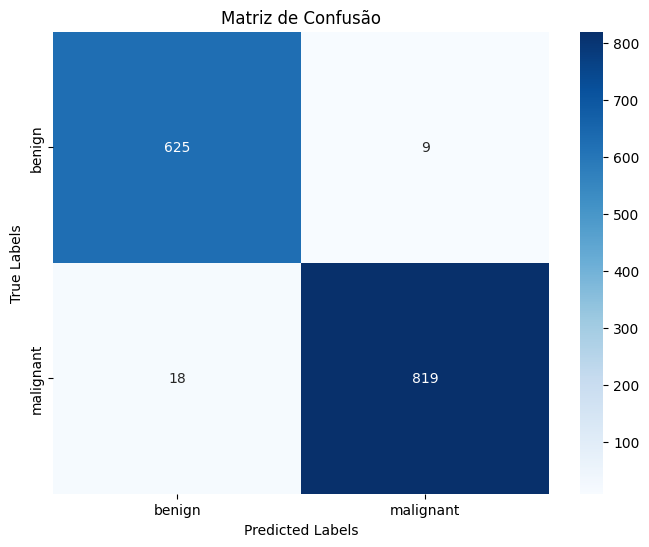

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mostrar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['benign', 'malignant'],
            yticklabels=['benign', 'malignant'])
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Matriz de Confusão')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


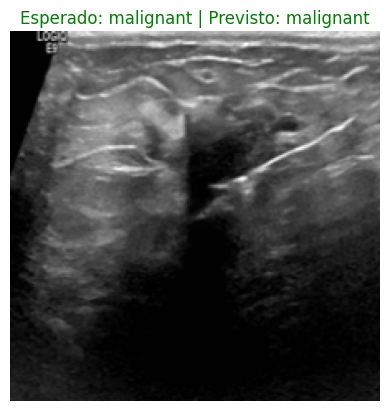

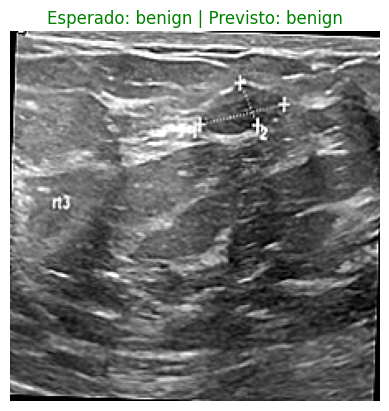

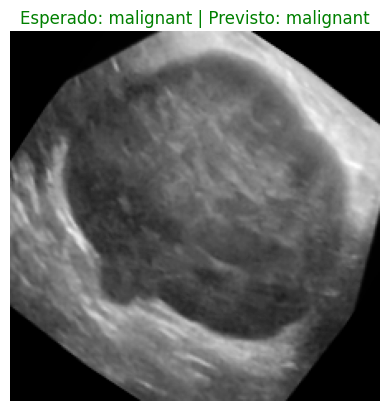

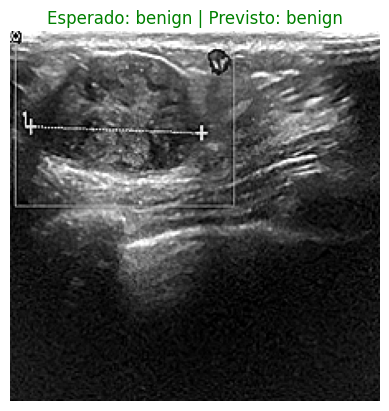

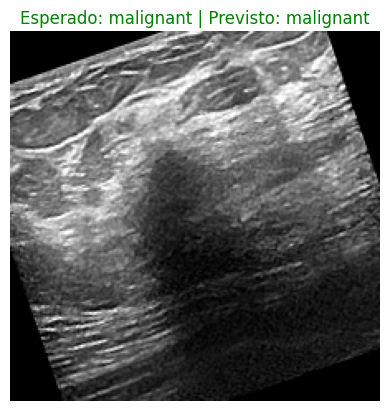

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Dicionário com as duas classes
class_names = {0: 'benign', 1: 'malignant'}

# Número de amostras que você quer prever
num_samples = 5

# Predição
predictions = model.predict(X_test[:num_samples])
predicted_classes = np.argmax(predictions, axis=1)

# Mostrar as imagens com a classe real e a prevista
for i in range(num_samples):
    plt.imshow(X_test[i].squeeze(), cmap='gray')  # .squeeze() remove canal extra se tiver
    esperado = class_names[y_test[i]]
    previsto = class_names[predicted_classes[i]]
    cor_titulo = 'green' if esperado == previsto else 'red'
    
    plt.title(f"Esperado: {esperado} | Previsto: {previsto}", color=cor_titulo)
    plt.axis('off')
    plt.show()


In [27]:
import os
import cv2
import numpy as np

# Caminhos das pastas
benign_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/val/benign'
malignant_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/val/malignant'

# Parâmetros
img_sz = 224
class_names = {0: 'benign', 1: 'malignant'}

def load_images_from_folder(folder_path, label):
    images = []
    labels = []

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            img = cv2.resize(img, (img_sz, img_sz))
            img = img.astype('float32') / 255.0
            img = np.expand_dims(img, axis=-1)  # (224, 224, 1)

            images.append(img)
            labels.append(label)

    return images, labels


In [28]:
benign_imgs, benign_labels = load_images_from_folder(benign_path, 0)
malignant_imgs, malignant_labels = load_images_from_folder(malignant_path, 1)

X_val = np.array(benign_imgs + malignant_imgs)
y_val = np.array(benign_labels + malignant_labels)

print(f'Total de imagens: {X_val.shape[0]}')
print(f'Benign: {np.sum(y_val == 0)} | Malignant: {np.sum(y_val == 1)}')


Total de imagens: 900
Benign: 500 | Malignant: 400


In [29]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Accuracy on test set: {accuracy*100:.2f}%")

Accuracy on test set: 86.00%


In [30]:
from sklearn.metrics import confusion_matrix

# Predição
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Matriz de confusão
conf_mat = confusion_matrix(y_val, y_pred_classes)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step


In [54]:
from sklearn.metrics import classification_report
import numpy as np

# 🔹 Predições no conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 🔹 Checagem de consistência (ESSENCIAL)
print(len(y_val), len(y_pred_classes))  # Deve ser: 900 900

# 🔹 Relatório de classificação
print(classification_report(
    y_val,
    y_pred_classes,
    target_names=['benign', 'malignant']
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
900 900
              precision    recall  f1-score   support

      benign       0.82      0.95      0.88       500
   malignant       0.93      0.74      0.83       400

    accuracy                           0.86       900
   macro avg       0.87      0.85      0.85       900
weighted avg       0.87      0.86      0.86       900



29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
900 900


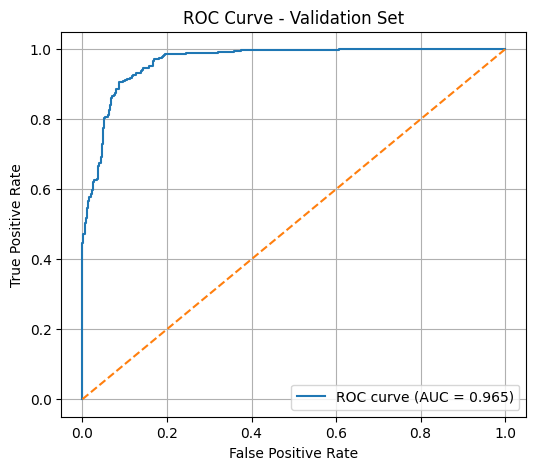

In [55]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 🔹 1. Recalcular predições com o conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)

# 🔹 2. Pegar probabilidade da classe positiva (malignant = 1)
y_scores = y_pred_probs[:, 1]

# 🔹 3. Conferência (boa prática)
print(len(y_val), len(y_scores))  # Deve ser: 900 900

# 🔹 4. Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)

# 🔹 5. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

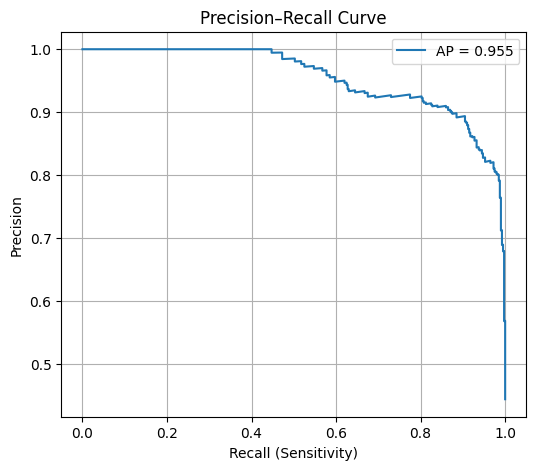

In [58]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, y_scores)
ap_score = average_precision_score(y_val, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [59]:
print(len(y_val), len(y_pred_classes))

900 900


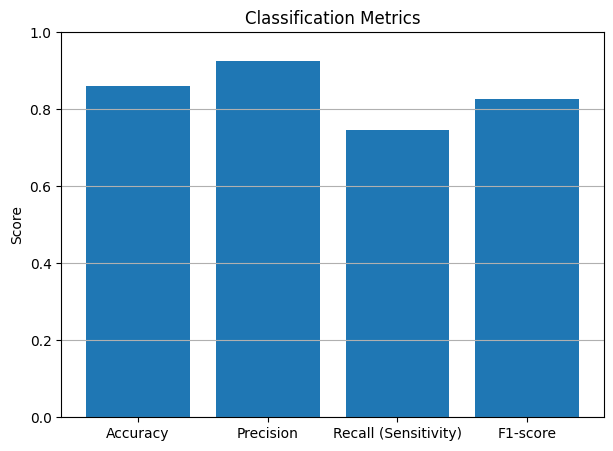

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred_classes)
precision = precision_score(y_val, y_pred_classes)
recall = recall_score(y_val, y_pred_classes)   # Sensibilidade (malignant)
f1 = f1_score(y_val, y_pred_classes)

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'F1-score': f1
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classification Metrics')
plt.grid(axis='y')
plt.show()


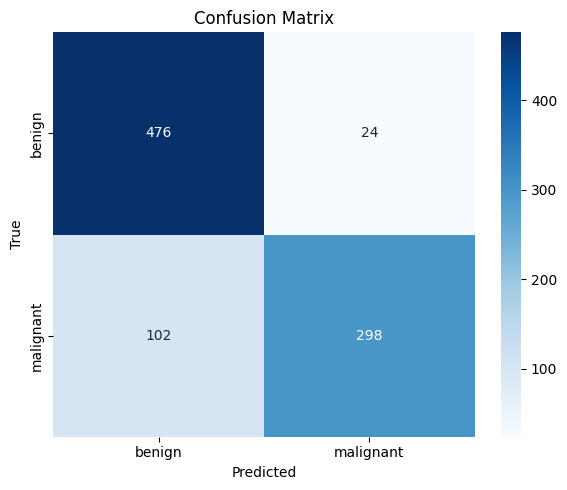

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['benign', 'malignant'],
    yticklabels=['benign', 'malignant']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


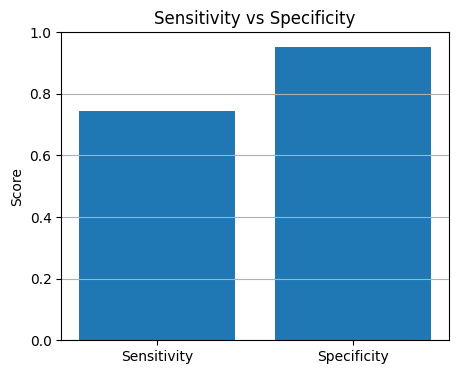

In [62]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

plt.figure(figsize=(5, 4))
plt.bar(['Sensitivity', 'Specificity'], [sensitivity, specificity])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Sensitivity vs Specificity')
plt.grid(axis='y')
plt.show()


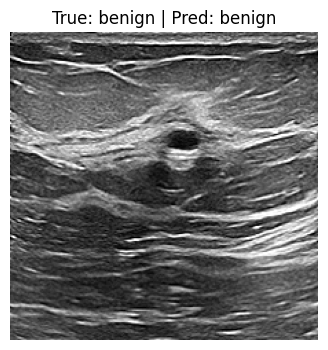

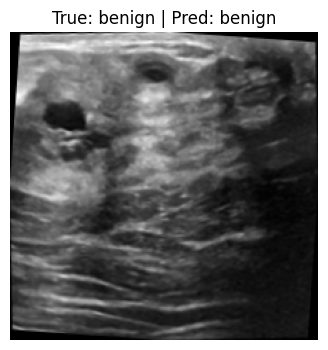

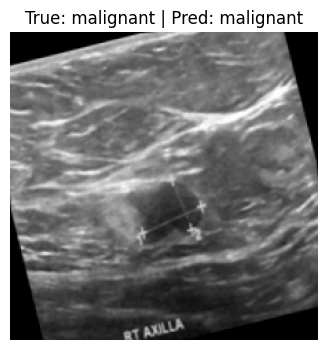

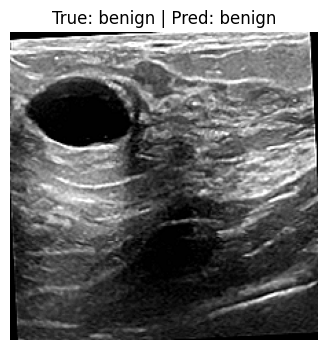

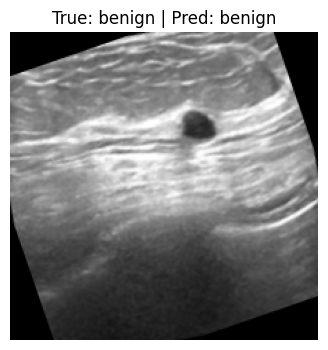

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Número de imagens para visualização
num_images = 5

# (Opcional) Para reprodutibilidade
np.random.seed(42)

for _ in range(num_images):
    # Índice aleatório
    random_idx = np.random.randint(0, len(X_val))

    # Imagem
    img = X_val[random_idx].squeeze()

    # Rótulos
    true_label = class_names[y_val[random_idx]]
    pred_label = class_names[y_pred_classes[random_idx]]

    # Plot
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
    plt.show()
